## **source cell**

In [2]:
import numpy as np
import random as rd
import pandas as pd
import math
import secrets as st
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter
import itertools
from scipy.spatial import cKDTree

time_step = 1
v = 0.3
def initialize() :
    global N, L, positions, directions, order_parameters
    positions = np.zeros((N, T, 2))
    directions = np.zeros((N, T))
    positions[:, 0, :] = np.random.uniform(0, L, (N, 2))
    directions[:, 0] = np.random.uniform(0, 2*np.pi, (N, 1))

def update(t) :
    global R, v, etta, new_xs, new_ys, new_dirs, order_parameter

    #positions update
    v_vector = np.column_stack([
        np.cos(directions[:, t-1]),
        np.sin(directions[:, t-1])
    ])
    positions[:, t, :] = positions[:, t-1, :] + v_vector*time_step

    #neighbors
    tree = cKDTree(positions)
    neighbors_lists = tree.query_ball_tree(tree, R)

    #direction update
    for i in range(len(neighbors_lists)) :
        x_dirs = np.cos(directions[neighbors_lists[i], t-1])
        y_dirs = np.sin(directions[neighbors_lists[i], t-1])
        directions[i, t] = math.atan(np.mean(y_dirs)/np.mean(x_dirs))

def animation() :
    global T
    fig, ax = plt.subplots()
    ax.set_xlim(0, L)
    ax.set_ylim(0, L)
    quiver = ax.quiver(x_positions[0], y_positions[0],
                        np.cos(directions[0]), np.sin(directions[0]),
              color='blue', scale=20, width=0.005)
    individual_arrow = ax.quiver([x_positions[0][individual_particle]],
                                [y_positions[0][individual_particle]],
                                [np.cos(directions[0][individual_particle])],
                                [np.sin(directions[0][individual_particle])],
                                color='red', scale=20, width=0.005)
    def update0(frame):
      quiver.set_offsets(np.column_stack((x_positions[frame], y_positions[frame])))
      quiver.set_UVC(np.cos(directions[frame]), np.sin(directions[frame]))
      individual_arrow.set_offsets(np.column_stack((
                [x_positions[frame][individual_particle]],
                [y_positions[frame][individual_particle]])))
      individual_arrow.set_UVC([np.cos(directions[frame][individual_particle])],
                               [np.sin(directions[frame][individual_particle])])
      return quiver, individual_arrow,
    ani = FuncAnimation(fig, update0, frames=T, interval=300, blit=True)
    ax.set_title(f"N={N}   L={L}   v={v}   R={R}   etta={etta}   T={T}")
    ani.save(f"../../animations/sample{sample}.gif")

def run_simulation() :
  global directions, order_parameters
  initialize()
  for t in range(99) :
    update()
    observe()



#order parameter

## **parameter combinations**

## **data producing**

MovieWriter ffmpeg unavailable; using Pillow instead.


2


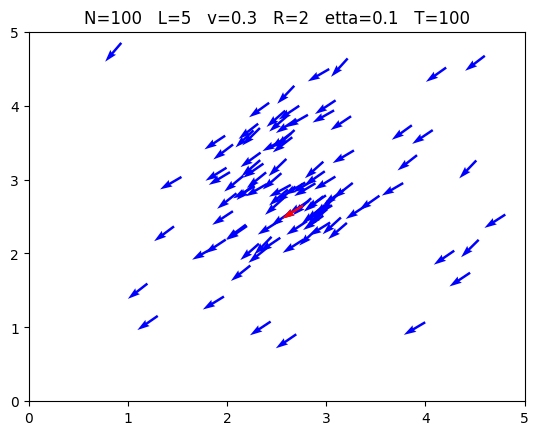

In [3]:
n_samples = 2
count = n_samples
dataset = []
N = 100
L = 5
etta = 0.1
R = 2
density = 50/(1.5**2)
for sample in range(1, n_samples) :
  global N, L, density, R, etta
  individual_particle = rd.randint(0, N-1)
  run_simulation()
  T = len(order_parameters)
  if 1000*sample%n_samples == 0 :
      animation()
  individuals_dirs = [ i[individual_particle] for i in directions ]
  data = [order_parameters[-1],
          order_parameters,
          individuals_dirs,
          density,
          R,
          etta]
  dataset.append(data)
  print(count)
  count-=1